In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Dataset Engine Channels Loaded.
X_train Shape: (63544, 255, 3) -> y_train Labels: (63544,)
X_test Shape : (15840, 255, 3)  -> y_test Labels : (15840,)
Training 1D-CNN on engine platform: cuda

Starting Pure 1D-CNN Model Training...
Epoch [01/20] | Train Loss: 1.1053 (52.63% Acc) | Test Loss: 0.8571 (65.70% Test Acc)
Epoch [02/20] | Train Loss: 0.9104 (62.72% Acc) | Test Loss: 0.7071 (72.44% Test Acc)
Epoch [03/20] | Train Loss: 0.8269 (66.82% Acc) | Test Loss: 0.6200 (76.21% Test Acc)
Epoch [04/20] | Train Loss: 0.7817 (68.78% Acc) | Test Loss: 0.5904 (77.30% Test Acc)
Epoch [05/20] | Train Loss: 0.7437 (70.64% Acc) | Test Loss: 0.5533 (78.66% Test Acc)
Epoch [06/20] | Train Loss: 0.7198 (71.56% Acc) | Test Loss: 0.5314 (79.46% Test Acc)
Epoch [07/20] | Train Loss: 0.6962 (72.73% Acc) | Test Loss: 0.5142 (80.31% Test Acc)
Epoch [08/20] | Train Loss: 0.6790 (73.43% Acc) | Test Loss: 0.4981 (80.86% Test Acc)
Epoch [09/20] | Train Loss: 0.6685 (73.86% Acc) | Test Loss: 0.4878 (81.35% Test

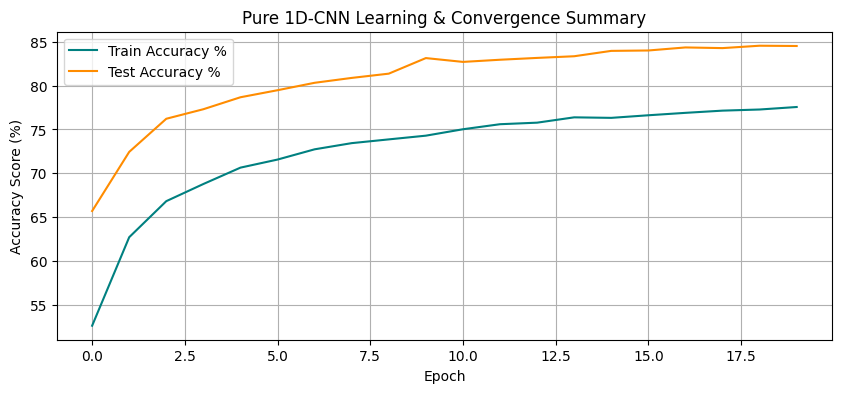

In [1]:
# ============================================================
# END-TO-END EEG PURE 1D-CNN INTENT CLASSIFIER
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# ============================================================
# 1. LOAD DATASETS (Inputs & Categorical 1D Direction Labels)
# ============================================================

# Features: (samples, 255, 3) | Labels: (samples,)
X_train = np.load("/kaggle/input/datasets/alekhya7gangopadhyay/eeg-processed/X_train_500.npy")
X_test  = np.load("/kaggle/input/datasets/alekhya7gangopadhyay/eeg-processed/X_test_500.npy")
y_train = np.load("/kaggle/input/datasets/alekhya7gangopadhyay/eeg-processed/y_train_cls_500.npy")
y_test  = np.load("/kaggle/input/datasets/alekhya7gangopadhyay/eeg-processed/y_test_cls_500.npy")

print("Dataset Engine Channels Loaded.")
print(f"X_train Shape: {X_train.shape} -> y_train Labels: {y_train.shape}")
print(f"X_test Shape : {X_test.shape}  -> y_test Labels : {y_test.shape}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training 1D-CNN on engine platform:", device)

# Convert arrays into PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# ============================================================
# 2. MINI-BATCH DATALOADERS SETUP
# ============================================================

BATCH_SIZE = 256

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# 3. PURE 1D-CNN CLASSIFIER ARCHITECTURE DEFINITION
# ============================================================

class EEG_Pure_1DCNN_Classifier(nn.Module):
    def __init__(self, input_dim=3, num_classes=4):
        super().__init__()
        
        # Deep Feature Extraction Backbone
        self.features = nn.Sequential(
            # Block 1: Captures broad frequency transitions
            nn.Conv1d(in_channels=input_dim, out_channels=64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2),  # Pulls 255 steps down to ~127
            nn.Dropout1d(0.3),
            
            # Block 2: Extracts intermediate structural waveforms
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2),  # Pulls 127 steps down to ~63
            nn.Dropout1d(0.3),
            
            # Block 3: Resolves tight, high-frequency intentional micro-bursts
            nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            
            # Global Average Pooling flattens out temporal shifts completely
            nn.AdaptiveAvgPool1d(1)  # Collapses output dimension to (batch, 256, 1)
        )
        
        # Linear Decoding Classification Head
        self.classifier_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Transpose from (batch, sequence_len, channels) to (batch, channels, sequence_len)
        x = x.transpose(1, 2)
        
        # Pass through convolutions and squeeze spatial trailing dimensions
        feats = self.features(x).squeeze(-1)  # Shape: (batch, 256)
        
        # Map through classification dense network
        logits = self.classifier_head(feats)
        return logits

# ============================================================
# 4. OPTIMIZATION & SCHEDULER SETUP
# ============================================================

model = EEG_Pure_1DCNN_Classifier(input_dim=3, num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

# ============================================================
# 5. CORE OPTIMIZATION CLASSIFICATION LOOP
# ============================================================

EPOCHS = 20
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_test_acc = 0.0

print("\nStarting Pure 1D-CNN Model Training...")
for epoch in range(EPOCHS):
    
    # --- Training State ---
    model.train()
    total_train_loss = 0
    correct_train = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item() * X_batch.size(0)
        preds = torch.argmax(logits, dim=1)
        correct_train += (preds == y_batch).sum().item()
        
    avg_train_loss = total_train_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / len(train_loader.dataset)) * 100
    
    # --- Evaluation State ---
    model.eval()
    total_test_loss = 0
    correct_test = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            
            total_test_loss += loss.item() * X_batch.size(0)
            preds = torch.argmax(logits, dim=1)
            correct_test += (preds == y_batch).sum().item()
            
    avg_test_loss = total_test_loss / len(test_loader.dataset)
    epoch_test_acc = (correct_test / len(test_loader.dataset)) * 100
    
    # Adapt learning rate based on test validation trends
    scheduler.step(epoch_test_acc)
    
    train_losses.append(avg_train_loss)
    test_losses.append(avg_test_loss)
    train_accs.append(epoch_train_acc)
    test_accs.append(epoch_test_acc)
    
    if epoch_test_acc > best_test_acc:
        best_test_acc = epoch_test_acc
        torch.save(model.state_dict(), "/kaggle/working/EEG_pure_1DCNN_classifier.pth")
        
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"| Train Loss: {avg_train_loss:.4f} ({epoch_train_acc:.2f}% Acc) "
          f"| Test Loss: {avg_test_loss:.4f} ({epoch_test_acc:.2f}% Test Acc)")

print(f"\nTraining Complete. Best Test Accuracy: {best_test_acc:.2f}%")
print("Saved active model weights to: /kaggle/working/EEG_pure_1DCNN_classifier.pth")

# ============================================================
# 6. EXPORT METRIC PLOT
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(train_accs, color='teal', label='Train Accuracy %')
plt.plot(test_accs, color='darkorange', label='Test Accuracy %')
plt.title("Pure 1D-CNN Learning & Convergence Summary")
plt.xlabel("Epoch")
plt.ylabel("Accuracy Score (%)")
plt.legend()
plt.grid(True)
plt.savefig("/kaggle/working/cnn_accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [1]:
# ============================================================
# STANDALONE TESTING WORKBOOK: PURE 1D-CNN PREDICTIONS
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from collections import Counter

class EEG_Pure_1DCNN_Classifier(nn.Module):
    def __init__(self, input_dim=3, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Dropout1d(0.3),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Dropout1d(0.3),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        feats = self.features(x).squeeze(-1)
        return self.classifier_head(feats)

NEW_UPLOADED_EXCEL = "/kaggle/input/datasets/alekhya7gangopadhyay/for-test/For.xlsx"
MODEL_WEIGHTS_PATH = "/kaggle/working/EEG_pure_1DCNN_classifier.pth"

SELECTED_CHANNELS = ["P4 - O2", "P3 - O1", "F4 - C4"]
EXPECTED_TIMESTEPS = 256
DIRECTION_MAP = {0: "RIGHT", 1: "LEFT", 2: "FORWARD", 3: "BACKWARD"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    df = pd.read_excel(NEW_UPLOADED_EXCEL)
    df_selected = df[SELECTED_CHANNELS]
    raw_values = df_selected.values.astype(np.float32)
    
    if raw_values.shape[0] >= EXPECTED_TIMESTEPS:
        num_windows = raw_values.shape[0] // EXPECTED_TIMESTEPS
        X_eval = raw_values[:num_windows * EXPECTED_TIMESTEPS].reshape(num_windows, EXPECTED_TIMESTEPS, 3)
        
        # Real-time sample standardization
        X_eval_2d = X_eval.reshape(-1, 3)
        mean, std = np.mean(X_eval_2d, axis=0), np.std(X_eval_2d, axis=0)
        std = np.where(std == 0, 1e-8, std)
        X_eval = ((X_eval_2d - mean) / std).reshape(num_windows, EXPECTED_TIMESTEPS, 3)
        
        X_tensor = torch.tensor(X_eval, dtype=torch.float32).to(device)
    else:
        raise ValueError("Excel file row length too short.")
except Exception as e:
    print(f"Data Error: {e}"); exit()

model = EEG_Pure_1DCNN_Classifier(input_dim=3, num_classes=4).to(device)
model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
model.eval()

with torch.no_grad():
    logits = model(X_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_indices = torch.argmax(probabilities, dim=1).cpu().numpy()
    confidence_scores = probabilities.cpu().numpy()

print("\n==================================================")
print("          1D-CNN WINDOW SEGMENT ANALYSIS          ")
print("==================================================")
for i, pred_idx in enumerate(predicted_indices):
    print(f"Segment #{i+1:02d} | Intent: ➔ 【 {DIRECTION_MAP[pred_idx]} 】 (Confidence: {confidence_scores[i, pred_idx]*100:.2f}%)")

prediction_counts = Counter(predicted_indices)
final_winning_idx = prediction_counts.most_common(1)[0][0]
avg_confidence = np.mean([confidence_scores[i, final_winning_idx] for i, p in enumerate(predicted_indices) if p == final_winning_idx]) * 100

print("\n==================================================")
print("              FINAL PIPELINE PREDICTION           ")
print("==================================================")
print(f"★ OVERARCHING PREDICTION : ➔ 【 {DIRECTION_MAP[final_winning_idx]} 】")
print(f"★ CONSENSUS CONFIDENCE   : {avg_confidence:.2f}%")
print("==================================================")


          1D-CNN WINDOW SEGMENT ANALYSIS          
Segment #01 | Intent: ➔ 【 RIGHT 】 (Confidence: 54.31%)
Segment #02 | Intent: ➔ 【 FORWARD 】 (Confidence: 55.41%)
Segment #03 | Intent: ➔ 【 FORWARD 】 (Confidence: 75.43%)
Segment #04 | Intent: ➔ 【 RIGHT 】 (Confidence: 54.04%)
Segment #05 | Intent: ➔ 【 FORWARD 】 (Confidence: 44.91%)
Segment #06 | Intent: ➔ 【 FORWARD 】 (Confidence: 54.27%)
Segment #07 | Intent: ➔ 【 BACKWARD 】 (Confidence: 50.91%)
Segment #08 | Intent: ➔ 【 BACKWARD 】 (Confidence: 80.33%)
Segment #09 | Intent: ➔ 【 BACKWARD 】 (Confidence: 55.02%)

              FINAL PIPELINE PREDICTION           
★ OVERARCHING PREDICTION : ➔ 【 FORWARD 】
★ CONSENSUS CONFIDENCE   : 57.51%
